# Ωm–S8 figure of merit across parameter space (general run comparison)

Per-observation constraining power for **any set of inference runs** that wrote posterior
chains. Point `RUNS_DIR` / `RUN_GLOBS` at the runs you want to compare and everything below
adapts automatically.

**Default configuration:** the **t2 transformer benchmark** for the weak-lensing maps probe in
`runs/v16/rot_in_place/maps/lensing` (`t2_default`, `t2_deep`, `t2_fp32`, `t2_full`,
`t2_wide`, `t2_global`, ...), compared **at 100k training steps** (`EVAL_STEP = 100000`), with
`t2_default` as the highlighted reference.

For each held-out mock observation the inference pipeline wrote a posterior chain to
`ensemble_flow_<step>/mcmc_samples.h5`, where `<step>` is the model training step
(`model.get_step()`) at which the summaries were evaluated. From the 2D marginal in the Ωm–S8
plane we define

$$\mathrm{FoM} = \frac{1}{\sqrt{\det \mathrm{Cov}(\Omega_m, S_8)}}, \qquad S_8 = \sigma_8\sqrt{\Omega_m/0.3}.$$

A larger FoM = a tighter 2D constraint. Because every observation has a different *true*
cosmology, plotting each observation's FoM at its true (Ωm, S8) shows **how constraining
power varies with location in parameter space** — and comparing runs at the same locations
isolates which compression extracts more information where.

> Only needs `numpy`, `h5py`, `matplotlib` — no TensorFlow/PyTorch — so it is safe to run on a
> login node. `EVAL_STEP` pins the training step every run is compared at (keeps the comparison
> apples-to-apples as continuation rounds add later checkpoints); set it to `None` to auto-pick
> each run's latest chain instead.

In [ ]:
import os, glob, re
import numpy as np
import h5py
import matplotlib.pyplot as plt

# RUNS_DIR = '/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/maps/lensing'
RUNS_DIR = '/users/athomsen/scratch/deep_lss/runs/v17/baseline/maps/lensing'
# RUNS_DIR = '/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/lensing'
# RUNS_DIR = '/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/combined'
# EVAL_STEP pins the training step (model.get_step()) each run is compared at, i.e. the
# ensemble_flow_<step>/ subdir. Set to 100000 for a strict apples-to-apples comparison at 100k
# steps; leave None to auto-pick each run's highest-step chain (then §1 warns if they differ).
# EVAL_STEP = 100000
EVAL_STEP = None
MCMC_FILE = 'mcmc_samples.h5'

# training-param order (from configs.yaml). Lensing/combined: [Om, s8, w0, Aia, n_Aia, bta]
I_OM, I_S8 = 0, 1

def s8_of(sigma8, Om):
    return sigma8 * np.sqrt(Om / 0.3)

## 1. Discover runs and load chains

Runs matching `RUN_GLOBS` that have an `ensemble_flow_<step>/mcmc_samples.h5` are picked up
automatically. With `EVAL_STEP` set, every run is taken at that exact training step; with
`EVAL_STEP = None` each run's highest-step chain is used and a warning fires if the runs don't
all resolve to the same step. Runs whose inference stage hasn't written the requested chain yet
(a continuation round still training, or a crashed run) are simply absent.

In [18]:
# RUN_GLOBS = ['t2_*']          # which runs to compare
# HIGHLIGHT = 't2_default'      # reference run, highlighted in every plot
# RUN_GLOBS = ['t3_*', "v8_cls", "t4_*"]
# RUN_GLOBS = ["t4_*", 't6_*', "t7_*", "v8_cls", "default_*"]
# RUN_GLOBS = ["t4_*", 't6_*', "t7_*", "v8_cls"]
# RUN_GLOBS = ['t6_*', "t7_*", "t8_*", "v8_cls"]
RUN_GLOBS = ["t8_*"]
HIGHLIGHT = "t8_default"
# HIGHLIGHT = "v8_cls"

# HIGHLIGHT = None

# RUN_GLOBS = ["m1_*"]
# RUN_GLOBS = ['v39', 'v39_*']
# HIGHLIGHT = "v39"

def _step_of(path):
    m = re.search(r'ensemble_flow_(\d+)', path)
    return int(m.group(1)) if m else -1

def find_mcmc(run_dir):
    '''Return (mcmc_path, step) for a run dir. Pins to EVAL_STEP if set, else the highest step.'''
    if EVAL_STEP is not None:
        f = os.path.join(run_dir, f'ensemble_flow_{EVAL_STEP}', MCMC_FILE)
        return (f, EVAL_STEP) if os.path.isfile(f) else (None, None)
    cands = glob.glob(os.path.join(run_dir, 'ensemble_flow_*', MCMC_FILE))
    if not cands:
        return (None, None)
    best = max(cands, key=_step_of)   # numeric, so 100000 > 90000
    return (best, _step_of(best))

def discover_runs(runs_dir=RUNS_DIR, patterns=RUN_GLOBS):
    found, steps = {}, {}
    for pat in patterns:
        for d in sorted(glob.glob(os.path.join(runs_dir, pat))):
            if not os.path.isdir(d):
                continue
            f, s = find_mcmc(d)
            if f is not None:
                found[os.path.basename(d)] = f
                steps[os.path.basename(d)] = s
    return dict(sorted(found.items())), steps

runs, run_steps = discover_runs()
print(f'{len(runs)} runs with {MCMC_FILE}'
      + (f' at step {EVAL_STEP}:' if EVAL_STEP is not None else ' (latest step each):'))
for k in runs:
    tag = '  <-- REFERENCE' if k == HIGHLIGHT else ''
    print(f'   {k:14s} step={run_steps[k]}{tag}')
assert runs, f'no runs matched {RUN_GLOBS} under {RUNS_DIR} — check RUNS_DIR / RUN_GLOBS / EVAL_STEP'
if HIGHLIGHT not in runs:  # None (the m1_* preset) or a mismatched name -> pick a reference, don't crash
    _prev = HIGHLIGHT
    HIGHLIGHT = next(iter(runs))
    print(f'  (reference {_prev!r} not among discovered runs -> using {HIGHLIGHT!r})')
_uniq = set(run_steps.values())
if len(_uniq) > 1:
    print(f'\n  WARNING: runs are NOT all at the same training step: {sorted(_uniq)}.'
          f'\n  Set EVAL_STEP to compare at one step for an apples-to-apples comparison.')

6 runs with mcmc_samples.h5 (latest step each):
   t8_block_dropout step=150000
   t8_default     step=150000  <-- REFERENCE
   t8_flat        step=150000
   t8_masked      step=150000
   t8_multiscale  step=150000
   t8_no_dropout  step=150000


In [19]:
def load_run(path):
    '''Return dict with theta_true (n_obs,6), theta_sample (n_samp,n_obs,6), real_idx (n_obs,3).'''
    with h5py.File(path, 'r') as f:
        out = {
            'theta_true': f['theta_true'][:],
            'theta_sample': f['theta_sample'][:],
        }
        out['real_idx'] = f['real_idx'][:] if 'real_idx' in f else None
    return out

def per_obs_fom(theta_sample):
    '''Vectorized Ωm–S8 FoM = 1/sqrt(det Cov) per observation. theta_sample: (n_samp, n_obs, 6).'''
    Om = theta_sample[:, :, I_OM]                 # (n_samp, n_obs)
    S8 = s8_of(theta_sample[:, :, I_S8], Om)
    Om_c = Om - Om.mean(0, keepdims=True)
    S8_c = S8 - S8.mean(0, keepdims=True)
    n = Om.shape[0]
    c_oo = (Om_c * Om_c).sum(0) / (n - 1)
    c_ss = (S8_c * S8_c).sum(0) / (n - 1)
    c_os = (Om_c * S8_c).sum(0) / (n - 1)
    det = c_oo * c_ss - c_os ** 2
    det = np.clip(det, 1e-30, None)
    return 1.0 / np.sqrt(det)                     # (n_obs,)

def truth_om_s8(theta_true):
    Om = theta_true[:, I_OM]
    return Om, s8_of(theta_true[:, I_S8], Om)

data = {}
for name, path in runs.items():
    r = load_run(path)
    om_t, s8_t = truth_om_s8(r['theta_true'])
    data[name] = {
        'fom': per_obs_fom(r['theta_sample']),
        'om_true': om_t,
        's8_true': s8_t,
        'real_idx': r['real_idx'],
    }
    has_idx = 'yes' if r['real_idx'] is not None else 'NO (excluded from §4)'
    print(f"{name:16s} step={run_steps[name]:>7}  n_obs={len(data[name]['fom']):4d}  "
          f"median FoM={np.median(data[name]['fom']):8.1f}  real_idx={has_idx}")

t8_block_dropout step= 150000  n_obs=1000  median FoM=  1151.3  real_idx=yes
t8_default       step= 150000  n_obs=1000  median FoM=  1189.8  real_idx=yes
t8_flat          step= 150000  n_obs=1000  median FoM=  1138.4  real_idx=yes
t8_masked        step= 150000  n_obs=1000  median FoM=  1166.7  real_idx=yes
t8_multiscale    step= 150000  n_obs=1000  median FoM=  1081.0  real_idx=yes
t8_no_dropout    step= 150000  n_obs=1000  median FoM=  1186.8  real_idx=yes


## 2. Overall ranking (median FoM)

A single-number summary of constraining power per run (median over all observations).
This collapses the spatial information — the per-location view in §3 is the substantive one.

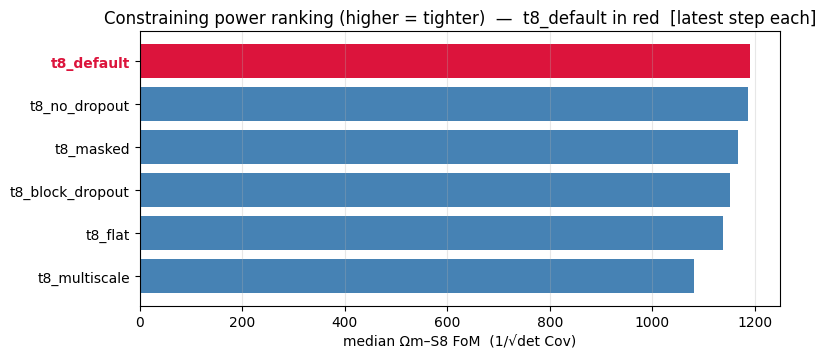

In [20]:
names = list(data)
med = np.array([np.median(data[n]['fom']) for n in names])
order = np.argsort(med)[::-1]

lab = [names[i] for i in order][::-1]
val = med[order][::-1]
col = ['crimson' if n == HIGHLIGHT else 'steelblue' for n in lab]
fig, ax = plt.subplots(figsize=(8, 0.45 * len(names) + 1))
ax.barh(lab, val, color=col)
for t in ax.get_yticklabels():
    if t.get_text() == HIGHLIGHT:
        t.set_color('crimson'); t.set_fontweight('bold')
ax.set_xlabel('median Ωm–S8 FoM  (1/√det Cov)')
step_lbl = f'step {EVAL_STEP}' if EVAL_STEP is not None else 'latest step each'
ax.set_title(f'Constraining power ranking (higher = tighter)  —  {HIGHLIGHT} in red  [{step_lbl}]')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.show()

## 3. How FoM varies with location in parameter space

Each point is one observation, placed at its **true** (Ωm, S8) and coloured by its FoM.
A shared colour scale (robust 2–98 percentile across all runs) makes panels comparable.

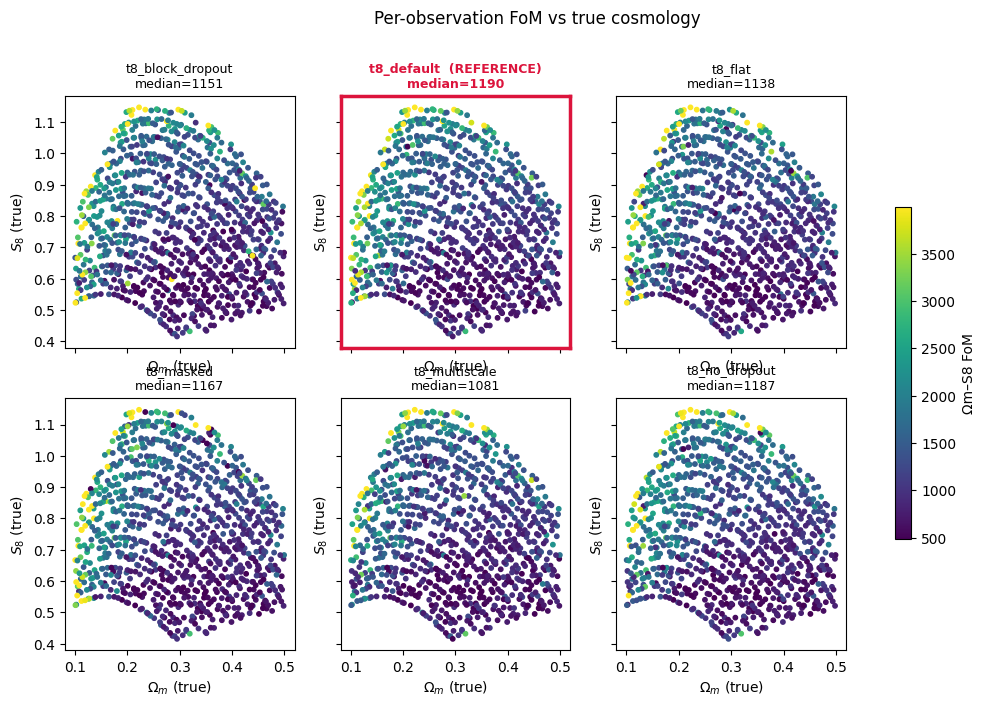

In [21]:
all_fom = np.concatenate([data[n]['fom'] for n in names])
vmin, vmax = np.percentile(all_fom, [2, 98])

ncol = 3
nrow = int(np.ceil(len(names) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.6 * nrow), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax in axes[len(names):]:
    ax.axis('off')

sc = None
for ax, n in zip(axes, names):
    d = data[n]
    sc = ax.scatter(d['om_true'], d['s8_true'], c=d['fom'], s=10,
                    cmap='viridis', vmin=vmin, vmax=vmax)
    hl = (n == HIGHLIGHT)
    ax.set_title(f"{n}{'  (REFERENCE)' if hl else ''}\nmedian={np.median(d['fom']):.0f}",
                 fontsize=9, color='crimson' if hl else 'black',
                 fontweight='bold' if hl else 'normal')
    if hl:
        for s in ax.spines.values():
            s.set_edgecolor('crimson'); s.set_linewidth(2.5)
    ax.set_xlabel(r'$\Omega_m$ (true)')
    ax.set_ylabel(r'$S_8$ (true)')
fig.colorbar(sc, ax=axes.tolist(), shrink=0.6, label='Ωm–S8 FoM')
fig.suptitle('Per-observation FoM vs true cosmology', y=1.0)
plt.show()

### 3b. 1D trends

Median FoM in bins of Ωm and of S8, overlaying all runs, to read off the dominant
dependence (lensing constraints typically tighten toward higher S8 / Ωm where the signal
is larger, and degrade near the prior edges).

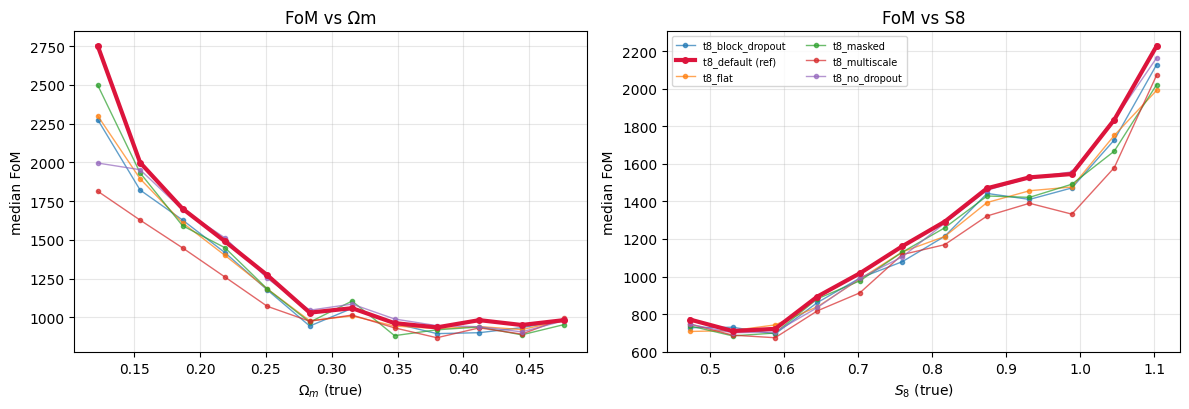

In [22]:
def binned_median(x, y, bins=12):
    edges = np.linspace(np.percentile(x, 1), np.percentile(x, 99), bins + 1)
    cen = 0.5 * (edges[:-1] + edges[1:])
    idx = np.digitize(x, edges) - 1
    med = np.array([np.median(y[idx == b]) if np.any(idx == b) else np.nan for b in range(bins)])
    return cen, med

fig, (axo, axs) = plt.subplots(1, 2, figsize=(12, 4.2))
for n in names:
    d = data[n]
    hl = (n == HIGHLIGHT)
    kw = dict(color='crimson', lw=3, marker='o', ms=4, zorder=5) if hl else dict(lw=1, marker='o', ms=3, alpha=0.7)
    c, m = binned_median(d['om_true'], d['fom'])
    axo.plot(c, m, label=(n + ' (ref)') if hl else n, **kw)
    c, m = binned_median(d['s8_true'], d['fom'])
    axs.plot(c, m, label=(n + ' (ref)') if hl else n, **kw)
axo.set_xlabel(r'$\Omega_m$ (true)'); axo.set_ylabel('median FoM')
axs.set_xlabel(r'$S_8$ (true)');     axs.set_ylabel('median FoM')
axo.set_title('FoM vs Ωm'); axs.set_title('FoM vs S8')
for a in (axo, axs):
    a.grid(alpha=0.3)
axs.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

## 4. Run-vs-run comparison at matched observations

The held-out set is identical across runs, so we can align observations by their
`real_idx = (i_sobol, i_signal, i_noise)` and compare FoM **per observation**. The map below
shows $\log_2(\mathrm{FoM}_{\rm run}/\mathrm{FoM}_{\rm ref})$ at each true cosmology: red =
this run is tighter than the reference there, blue = looser. This reveals *where* in
parameter space one compression beats another, not just on average.

Matching uses `real_idx` rather than row order (row order is **not** guaranteed identical
across runs). Any run whose `mcmc_samples.h5` predates the `real_idx` output is automatically
skipped here but still appears in §2–§3.

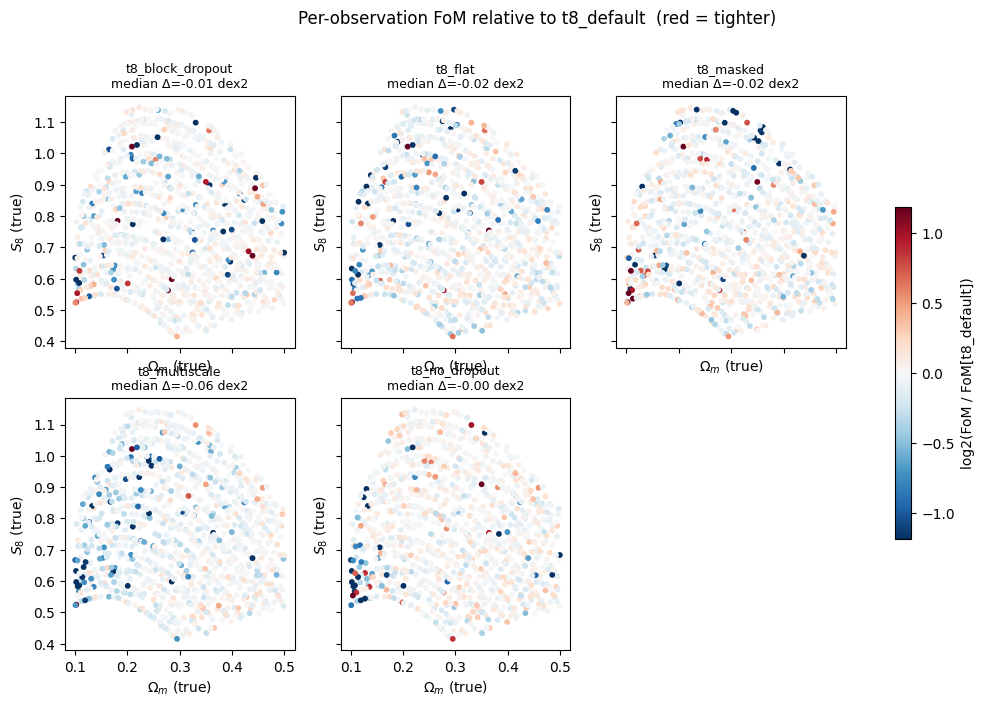

In [23]:
REFERENCE = HIGHLIGHT
assert REFERENCE in data, f'{REFERENCE} not found; pick from {list(data)}'

def idx_key(real_idx):
    return [tuple(int(v) for v in row) for row in real_idx]

ref = data[REFERENCE]
if ref['real_idx'] is None:
    raise RuntimeError('reference run has no real_idx; cannot align per observation')
ref_map = {k: i for i, k in enumerate(idx_key(ref['real_idx']))}

others = [n for n in names if n != REFERENCE and data[n]['real_idx'] is not None]
ncol = 3
nrow = max(1, int(np.ceil(len(others) / ncol)))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.6 * nrow), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax in axes[len(others):]:
    ax.axis('off')

sc = None
for ax, n in zip(axes, others):
    d = data[n]
    keys = idx_key(d['real_idx'])
    common = [(i, ref_map[k]) for i, k in enumerate(keys) if k in ref_map]
    if not common:
        ax.set_title(f'{n}\n(no matched obs)', fontsize=9); continue
    ii = np.array([a for a, _ in common]); jj = np.array([b for _, b in common])
    ratio = np.log2(d['fom'][ii] / ref['fom'][jj])
    lim = np.percentile(np.abs(ratio), 98)
    sc = ax.scatter(d['om_true'][ii], d['s8_true'][ii], c=ratio, s=10,
                    cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_title(f'{n}\nmedian Δ={np.median(ratio):+.2f} dex2', fontsize=9)
    ax.set_xlabel(r'$\Omega_m$ (true)'); ax.set_ylabel(r'$S_8$ (true)')
if sc is not None:
    fig.colorbar(sc, ax=axes.tolist(), shrink=0.6, label=f'log2(FoM / FoM[{REFERENCE}])')
fig.suptitle(f'Per-observation FoM relative to {REFERENCE}  (red = tighter)', y=1.0)
plt.show()

## 5. Notes

- **FoM is a 2D marginal metric** (Ωm–S8 only). The 6D parameter volume can move differently;
  swap `I_OM, I_S8` or extend `per_obs_fom` to a 6×6 determinant for a generalized FoM.
- **Constraining power ≠ calibration.** A higher FoM is only a real gain if the posteriors stay
  calibrated — cross-check the SBC/TARP/HPD plots in each run's `unblinding_plots/`. An
  overconfident run inflates FoM everywhere.
- **The comparison step matters.** `ensemble_flow_<step>` encodes the model training step, so
  `EVAL_STEP = 100000` compares every run at 100k steps. A continuation round writes a *new*
  `ensemble_flow_<higher_step>/` (the 100k one stays), so to compare at the longer training
  budget bump `EVAL_STEP` once all runs have reached it — §1 warns if you leave `EVAL_STEP=None`
  and the runs land on different steps.
- **t2 runs still absent:** runs mid-continuation (e.g. `t2_global`) or crashed with no chain
  (e.g. `t2_cls`) won't have a chain at the requested step until their inference stage writes one.
- To compare a **different** set (e.g. the cls runs), change `RUNS_DIR`, `RUN_GLOBS`,
  `HIGHLIGHT`, and `EVAL_STEP` (cls runs live at 1000000).